In [1]:
from transformers import AutoTokenizer
import json
from datasets import Dataset
import numpy as np
from skmultilearn.model_selection import iterative_train_test_split

In [8]:
file_path1 = "data/sample_new_1_14.jsonl"  # Update with your actual file path
with open(file_path1, "r") as f:
    data1 = [json.loads(line) for line in f]
    
file_path2 = "data/Demo_message.jsonl"  # Update with your actual file path
with open(file_path2, "r") as f:
    data2 = [json.loads(line) for line in f]

In [9]:
data1[0]

{'context': 'Ty very much.',
 'annotations': [{'start': 0,
   'end': 12,
   'text': 'Ty very much',
   'codes': ['PartnershipPatient', 'Appreciation/Gratitude']}],
 'meta': {'TO_PAT_YN': 'N', 'PAT_ID': 'Z1000037', 'MESSAGE_ID': 68856624}}

In [10]:
data = data1 + data2

In [13]:
len(data)

815

In [16]:
patids = []
for d in data:
    patids.append(d["meta"]["PAT_ID"])

In [17]:
len(patids)

815

In [19]:
len(set(patids))

213

In [21]:
patidset = list(set(patids))

In [22]:
patidset[0]

'Z5549918'

In [23]:
import json
import csv
import pandas as pd

with open("/home/lm2445/project_pi_sjf37/lm2445/pv_miner_process/PV_miner_data_processing/data/patID_to_Messages_duplicates_sorted.json", "r") as f:
    patID_to_lines = json.load(f)

In [25]:
def get_race_gender_age(patID):
    assert type(patID) == str
    #assert type(mgID) == int
    ret = None # ret is [race_gender_age]
    for line in patID_to_lines[patID]:
        features = line.split("|")
        #if str(mgID) == features[8]:
        #author = "provider" if features[3] == "Y" else "patient"
        ret = [features[-4], features[-5], features[-6]]
        break
    assert ret is not None
    return ret

get_race_gender_age("Z1000037")

['I Do Not See My Race Listed Here', 'Female', '59']

In [26]:
columns = ["race", "gender", "age"]
res = []
res.append(columns)
for pid in patidset:
    res.append(get_race_gender_age(pid))
len(res)


214

In [27]:
res

[['race', 'gender', 'age'],
 ['I Prefer Not To Share', 'Female', '80'],
 ['White', 'Male', '75'],
 ['White', 'Female', '31'],
 ['White', 'Male', '73'],
 ['White', 'Female', '25'],
 ['White', 'Female', '21'],
 ['Asian', 'Female', '33'],
 ['Black or African American', 'Male', '59'],
 ['White', 'Female', '66'],
 ['White', 'Male', '38'],
 ['White', 'Female', '50'],
 ['White', 'Male', '56'],
 ['White', 'Male', '55'],
 ['White', 'Female', '73'],
 ['White', 'Female', '38'],
 ['White', 'Female', '26'],
 ['White', 'Female', '60'],
 ['White', 'Male', '72'],
 ['White', 'Female', '56'],
 ['White', 'Male', '59'],
 ['White', 'Female', '36'],
 ['I Prefer Not To Share', 'Female', '59'],
 ['White', 'Female', '79'],
 ['White', 'Female', '66'],
 ['White', 'Female', '44'],
 ['White', 'Female', '51'],
 ['White', 'Female', '35'],
 ['White', 'Female', '38'],
 ['I Do Not See My Race Listed Here', 'Female', '38'],
 ['White', 'Male', '60'],
 ['White', 'Male', '26'],
 ['White', 'Female', '87'],
 ['White', 'Male'

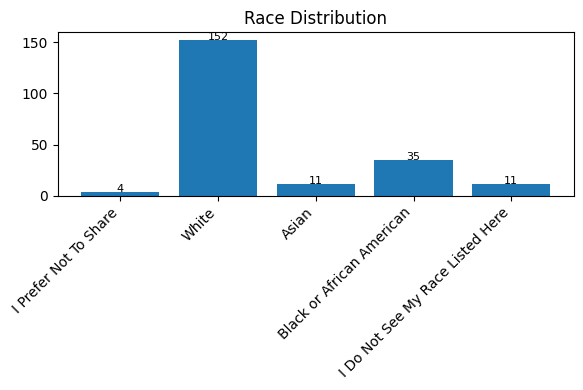

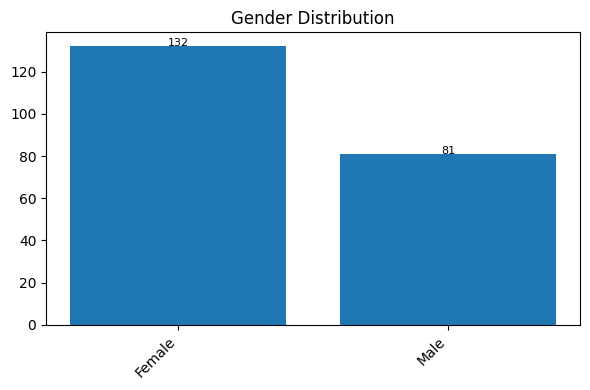

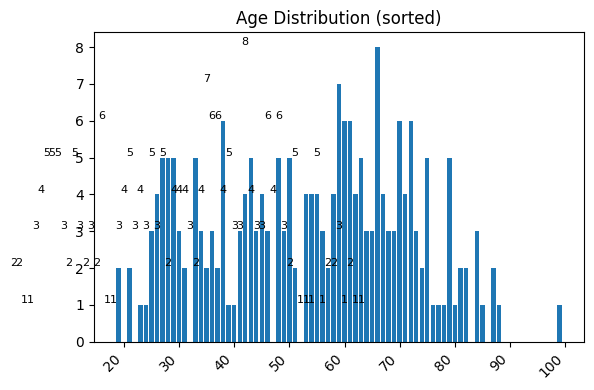

Saved distributions to feature_distributions.csv


In [28]:
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

# Sample data
data = res

# Separate header and data
header = data[0]
rows = data[1:]

# Initialize distributions
race_dist = defaultdict(int)
gender_dist = defaultdict(int)
age_dist = defaultdict(int)

# Populate counts
for row in rows:
    race, gender, age = row
    race_dist[race] += 1
    gender_dist[gender] += 1
    age_dist[int(age)] += 1  # convert to int for sorting

# Sort age by key
age_dist = dict(sorted(age_dist.items()))

# --- Plot helper function ---
def plot_distribution(dist, title):
    plt.figure(figsize=(6,4))
    keys = list(dist.keys())
    values = list(dist.values())
    plt.bar(keys, values)
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(values):
        plt.text(i, v + 0.05, str(v), ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

# Plot each distribution
plot_distribution(race_dist, "Race Distribution")
plot_distribution(gender_dist, "Gender Distribution")
plot_distribution(age_dist, "Age Distribution (sorted)")

# --- Save to CSV ---
# Create one combined table
max_len = max(len(race_dist), len(gender_dist), len(age_dist))
df = pd.DataFrame({
    'Race': list(race_dist.keys()) + [''] * (max_len - len(race_dist)),
    'Race_Count': list(race_dist.values()) + [None] * (max_len - len(race_dist)),
    'Gender': list(gender_dist.keys()) + [''] * (max_len - len(gender_dist)),
    'Gender_Count': list(gender_dist.values()) + [None] * (max_len - len(gender_dist)),
    'Age': list(age_dist.keys()) + [None] * (max_len - len(age_dist)),
    'Age_Count': list(age_dist.values()) + [None] * (max_len - len(age_dist)),
})

df.to_csv("feature_distributions.csv", index=False)
print("Saved distributions to feature_distributions.csv")
